In [58]:
from mGST.low_level_jit import contract_mps_all_povm, cost_function_jax_mps, cost_function_jax
from mGST.additional_fns import perturbed_target_init, sampled_measurements, random_seq_design

from mGST.utility_functions_comparisons import riemannian_metric, get_compressed_rep_from_mgst_output, get_compressed_rep_mgst_cholesky, tensor_to_isometry, create_2q_emerald_gst_config, Tensor, isometry_to_tensor, riemannian_hessian_vector_mgst, random_tangent_vector, cost_function_from_updated_operator, is_in_tangent_space, _update_tensor_via_gradient, update_povm_via_saddle_free_newton
from mGST.trust_region import riemannian_hessian_vector_povm_jax, riemannian_gradient_fn_povm, truncated_conjugate_gradient, run_trust_region_optimization, retraction_first_order, compute_quality_quotient, compute_step_size
from mGST.riemannian import get_isometry_dimensions_from_tensor
from mGST.algorithm import riemannian_hessian_povm
from mGST.visualization import plot_cost_function, plot_bars_with_error, average_and_error_of_sum, average_and_error_times_scalar

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import pickle
import jax
from typing import Callable


backend = "iqmfakeapollo"
data_path = "../data/"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Goals:
1. Develop the Trust-region algorithm.
2. Test that it can approximate the minimizer of the second order model $(H)^{-1} \mathrm{grad} f_x$ 

# Setup

In [2]:
Q2_GST_EMERALD = create_2q_emerald_gst_config()

with open(data_path +'emerald_2q_parallel_qubits_44__48.pkl', 'rb') as function:
    data = pickle.load(function)
    
X_true = data["X_true"]
E_true = data["E_true"]
rho_true = data["rho_true"]

K_target = data["K_target"]
X_target = data["X_target"]
E_target = data["E_target"]
rho_target = data["rho_target"]

# dimensions
dim = rho_true.shape[0]
num_povm = E_true.shape[0]
num_gates = X_true.shape[0]
bsize = 30 * dim
# Getting the values to be initialized
kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target = get_compressed_rep_from_mgst_output(X_target, E_target, rho_target, kraus_rank=dim**2, state_rank=dim, povm_rank=dim)

# Testing they are all correct
povm_jax_target = povm_psd_2q_target.conj().transpose(0, 2, 1) @ povm_psd_2q_target
superop_kraus_test = jnp.einsum("ijkl,ijnm -> iknlm", kraus_tensor_2q_target, kraus_tensor_2q_target.conj()).reshape((num_gates, dim**2, dim**2))

rho_target_matrix = rho_target.reshape(dim, dim)
povm_target_matrices = E_target.reshape(num_povm, dim, dim)

jnp.allclose(state_psd_2q_target @ state_psd_2q_target.conj().T, rho_target_matrix), jnp.allclose(povm_jax_target, povm_target_matrices), jnp.allclose(superop_kraus_test, X_target)

INFO:2025-09-10 15:31:08,194:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-09-10 15:31:08,194 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-09-10 15:31:08,197:jax._src.xla_bridge:927: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/

(Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool))

In [3]:
state_mgst_true = rho_true.reshape(-1)
povm_mgst_true = E_true.reshape(num_povm, -1)

kraus_tensor_2q_true, povm_psd_2q_true, state_psd_2q_true  = get_compressed_rep_from_mgst_output(X_true, povm_mgst_true, state_mgst_true, kraus_rank=dim**2, state_rank=dim, povm_rank=dim)

# Testing they are all correct
povm_jax = povm_psd_2q_true.conj().transpose(0, 2, 1) @ povm_psd_2q_true
superop_kraus_test = jnp.einsum("ijkl,ijnm -> iknlm", kraus_tensor_2q_true, kraus_tensor_2q_true.conj()).reshape((num_gates, dim**2, dim**2))

target_operators = [kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target]

jnp.allclose(state_psd_2q_true @ state_psd_2q_true.conj().T, rho_true), jnp.allclose(povm_jax, E_true), jnp.allclose(superop_kraus_test, X_true)

(Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool))

In [4]:
shots = 1000

N = 100  # Number of sequences
N_short = int(jnp.ceil(N / 2))
N_long = int(jnp.floor(N / 2))
meas_samples = 1e5  # Number of samples per sequences

# generate random numbers between 0 and $d^l - 1$
J = random_seq_design(num_gates, 1, 8, 14, N_short, N_long)
indices_list_2q = [indices[indices != -1] for indices in J]
# compute outcome probabilities
prob_matrix_exact = []
for indices in indices_list_2q:
    prob_matrix_exact.append(jnp.real(contract_mps_all_povm(kraus_tensor_2q_true, povm_psd_2q_true, state_psd_2q_true, indices)))
    
prob_matrix_exact = jnp.array(prob_matrix_exact).T
prob_matrix_2q_sampled = sampled_measurements(prob_matrix_exact, shots, seed=42)


In [5]:
kraus_rank = dim**2
kraus_init_mgst = perturbed_target_init(X_target, kraus_rank, seed=42)
x_init_mgst = jnp.einsum("ijkl,ijnm -> iknlm", kraus_init_mgst, kraus_init_mgst.conj()).reshape((num_gates, dim**2, dim**2))
povm_target_mgst = E_target.reshape(num_povm, -1)
rho_target_mgst = rho_target.reshape(-1)
init_mgst = [kraus_init_mgst, povm_target_mgst, rho_target_mgst]

povm_psd_init_jax, state_psd_init_jax = get_compressed_rep_mgst_cholesky(povm_target_mgst, rho_target_mgst)
kraus_tensor_init_jax = jnp.array(kraus_init_mgst)

povm_psd_init_mgst = np.array(povm_psd_init_jax)
state_psd_init_mgst = np.array(state_psd_init_jax)

# Initialize values

In [6]:
x = povm_psd_init_jax
n, p = get_isometry_dimensions_from_tensor(x, "povm")
num_iterations_cg = 20
metric = "canonical"
riemannian_gradient_function:Callable[[Tensor], Tensor] = lambda x: riemannian_gradient_fn_povm(kraus_tensor=kraus_tensor_init_jax, povm_psd=x, state_psd=state_psd_init_jax, indices_list=indices_list_2q, prob_matrix=prob_matrix_2q_sampled, operator_type="povm",metric=metric)

rhessian_vector_fn: Callable[[Tensor, Tensor], Tensor] = lambda x, tangent_vector: riemannian_hessian_vector_povm_jax(kraus_tensor=kraus_tensor_init_jax, povm_psd=x, state_psd=state_psd_init_jax, indices_list=indices_list_2q, prob_matrix=prob_matrix_2q_sampled, tangent_vector=tangent_vector,metric=metric)

gradient_init = riemannian_gradient_function(x) # using 2df/dx* convention

In [7]:
# First, check curvature.
rhessian_delta_tensor = rhessian_vector_fn(x=x, tangent_vector=gradient_init)
x_matrix = tensor_to_isometry(x, n=n, p=p)
gradient_init_matrix = tensor_to_isometry(gradient_init, n=n, p=p)
rhessian_delta_matrix = tensor_to_isometry(rhessian_delta_tensor, n=n, p=p)
curvature = riemannian_metric(gradient_init_matrix, rhessian_delta_matrix, x=x_matrix, metric=metric)
curvature

Array(3.25212699e-06, dtype=float64)

In [99]:
jnp.linalg.norm(gradient_init_matrix), riemannian_metric(gradient_init_matrix, gradient_init_matrix, x=x_matrix, metric=metric)

(Array(0.0076989, dtype=float64), Array(2.96365093e-05, dtype=float64))

In [ ]:
# Original cost function:
cost_fn_povm = lambda x: cost_function_jax_mps(
    kraus=kraus_tensor_init_jax,
    state_psd=state_psd_init_jax,
    povm_psd=x,
    indices_list=indices_list_2q,
    prob_matrix=prob_matrix_2q_sampled,
    jit=True)

tensor_shape = povm_psd_init_jax.shape
cost_fn_from_updated_povm_direction = lambda update_direction: cost_function_from_updated_operator(
        step_size=-1, # Due to the convention in the retraction of x - tz
        initial_isometry=x_matrix,
        update_direction=update_direction,
        tensor_shape=tensor_shape,
        operator_type="povm",
        kraus_tensor=kraus_tensor_init_jax,
        state_psd=state_psd_init_jax,
        indices_list=indices_list_2q,
        prob_matrix=prob_matrix_2q_sampled,
        use_geodesic=False,
        regularized=False
    )

In [11]:
initial_cost = cost_fn_povm(povm_psd_init_jax)
initial_cost

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 7 the new count changed to: 3
at iteration 13 the new count changed to: 4
at iteration 19 the new count changed to: 5
at iteration 25 the new count changed to: 6
at iteration 31 the new count changed to: 7
at iteration 37 the new count changed to: 8
at iteration 43 the new count changed to: 9
at iteration 50 the new count changed to: 10
at iteration 58 the new count changed to: 11
at iteration 66 the new count changed to: 12
at iteration 74 the new count changed to: 13
at iteration 82 the new count changed to: 14
at iteration 91 the new count changed to: 15


Array(0.00310091, dtype=float64)

# Test conjugate gradient

In [12]:
radius_test = 0.1
solution_tensor, on_boundary = truncated_conjugate_gradient(
    x=x, radius=radius_test, num_iterations=num_iterations_cg, rgradient=gradient_init, metric=metric, n=n, p=p, rhessian_vector_fn=rhessian_vector_fn, verbose=True
)

TCG started with radius: 0.1 🚀
Iteration 1/20
Iteration 2/20
Iteration 3/20
Iteration 4/20
Iteration 5/20
Iteration 6/20
Iteration 7/20
Exceeded trust region boundary.


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:107: RuntimeWarning: encountered t < 0: -57.20325071781303
  warnings.warn(f"encountered t < 0: {t}", RuntimeWarning)


In [13]:
solution_matrix = tensor_to_isometry(solution_tensor, n=n, p=p)
cost_fn_from_updated_povm_direction(solution_matrix)


Array(0.00293586, dtype=float64)

**NOTE**: Seems to be working!! Now the trust region outter loop!

# Trust region algorithm

In [87]:
radius_init = 0.1
num_iterations_tr = 20
max_radius = 2.0
quotient_trust = 0.125
retraction = lambda x, z: retraction_first_order(x, z, n=n, p=p)

In [ ]:
x_optimized, x_array_optimized, cost_fx_optimized = run_trust_region_optimization(
    cost_function=cost_fn_povm,
    retraction=retraction,
    x_init=x,
    radius_init=radius_init,
    num_iterations=num_iterations_tr,
    max_radius=max_radius,
    quotient_trust=quotient_trust,
    operator_type="povm",
    rgradient_fn=riemannian_gradient_function,
    rhessian_vector_fn=rhessian_vector_fn,
    metric_cg=metric,
    num_iterations_cg=num_iterations_cg,
    verbose_cg=True,
    verbose=True
)

TR Iteration: 0
TCG started with radius: 0.1 🚀
Iteration 1/20
Iteration 2/20
Iteration 3/20
Iteration 4/20
Iteration 5/20
Iteration 6/20
Iteration 7/20
Exceeded trust region boundary.


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:107: RuntimeWarning: encountered t < 0: -57.20325071781303
  warnings.warn(f"encountered t < 0: {t}", RuntimeWarning)


TR Iteration: 1
TCG started with radius: 0.2 🚀
Iteration 1/20
Iteration 2/20
Iteration 3/20
Iteration 4/20
Iteration 5/20
Iteration 6/20
Negative curvature encountered.
TR Iteration: 2
TCG started with radius: 0.4 🚀
Iteration 1/20
Iteration 2/20


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: tangent vector 'delta' has norm zero
  warnings.warn("tangent vector 'delta' has norm zero")


Negative curvature encountered.
TR Iteration: 3
TCG started with radius: 0.8 🚀
Iteration 1/20
Iteration 2/20


...

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:107: RuntimeWarning: encountered t < 0: -91.9006996120871
  warnings.warn(f"encountered t < 0: {t}", RuntimeWarning)


TCG started with radius: 0.2 🚀
Iteration 1/20
Iteration 2/20
Iteration 3/20
Iteration 4/20
Iteration 5/20
Iteration 6/20
Iteration 7/20
Iteration 8/20
Iteration 9/20
Iteration 10/20
Iteration 11/20
Iteration 12/20
Iteration 13/20
Iteration 14/20
Iteration 15/20
Iteration 16/20
Iteration 17/20
Iteration 18/20
Iteration 19/20
Negative curvature encountered.
Update rejected.
TR Iteration: 18
TCG started with radius: 0.05 🚀
Iteration 1/20
Iteration 2/20
Iteration 3/20
Iteration 4/20
Iteration 5/20
Iteration 6/20
Exceeded trust region boundary.


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:107: RuntimeWarning: encountered t < 0: -13.152098622045258
  warnings.warn(f"encountered t < 0: {t}", RuntimeWarning)


TR Iteration: 19
TCG started with radius: 0.1 🚀
Iteration 1/20
Iteration 2/20
Iteration 3/20
Iteration 4/20
Iteration 5/20
Iteration 6/20
Iteration 7/20
Iteration 8/20
Iteration 9/20
Iteration 10/20
Iteration 11/20
Iteration 12/20
Iteration 13/20
Exceeded trust region boundary.
Update rejected.


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:107: RuntimeWarning: encountered t < 0: -15.473069317732543
  warnings.warn(f"encountered t < 0: {t}", RuntimeWarning)


In [115]:
theta = 1
kappa = 0.1

x_optimized_test, x_array_optimized_test, cost_fx_optimized_test = run_trust_region_optimization(
    cost_function=cost_fn_povm,
    retraction=retraction,
    x_init=x,
    radius_init=radius_init,
    num_iterations=50,
    max_radius=max_radius,
    quotient_trust=quotient_trust,
    operator_type="povm",
    rgradient_fn=riemannian_gradient_function,
    rhessian_vector_fn=rhessian_vector_fn,
    metric_cg=metric,
    num_iterations_cg=30,
    verbose_cg=True,
    theta_cg=theta,
    kappa_cg=kappa,
    verbose=True
)

TR started 🚀.
TR Iteration: 0. f(x): 3.100913e-03. |r∇f(x)|: 5.443942e-03. Radius: 1.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:107: RuntimeWarning: encountered t < 0: -57.20325071781303
  warnings.warn(f"encountered t < 0: {t}", RuntimeWarning)


TCG finished after: 7/30 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 2.935864e-03. |r∇f(x)|: 4.170363e-04. Radius: 2.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: tangent vector 'delta' has norm zero
  warnings.warn("tangent vector 'delta' has norm zero")


TCG finished after: 6/30 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 2. f(x): 2.933876e-03. |r∇f(x)|: 1.659568e-05. Radius: 4.00e-01


...

TCG finished after: 6/30 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 26. f(x): 8.310243e-04. |r∇f(x)|: 5.228320e-04. Radius: 2.50e-02


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:107: RuntimeWarning: encountered t < 0: -7.372952027314644
  warnings.warn(f"encountered t < 0: {t}", RuntimeWarning)


TCG finished after: 5/30 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 27. f(x): 8.257652e-04. |r∇f(x)|: 6.733554e-05. Radius: 5.00e-02


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: tangent vector 'delta' has norm zero
  warnings.warn("tangent vector 'delta' has norm zero")


TCG finished after: 28/30 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 28. f(x): 8.254377e-04. |r∇f(x)|: 1.248692e-05. Radius: 1.00e-01
TCG finished after: 30/30 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
Stopping criteria met. 🛑
Optimization finished ✅. 
 Iters: 29. f(x): 8.254275e-04. |r∇f(x)|: 2.143737e-07. Radius: 1.00e-01. Rejections: 6


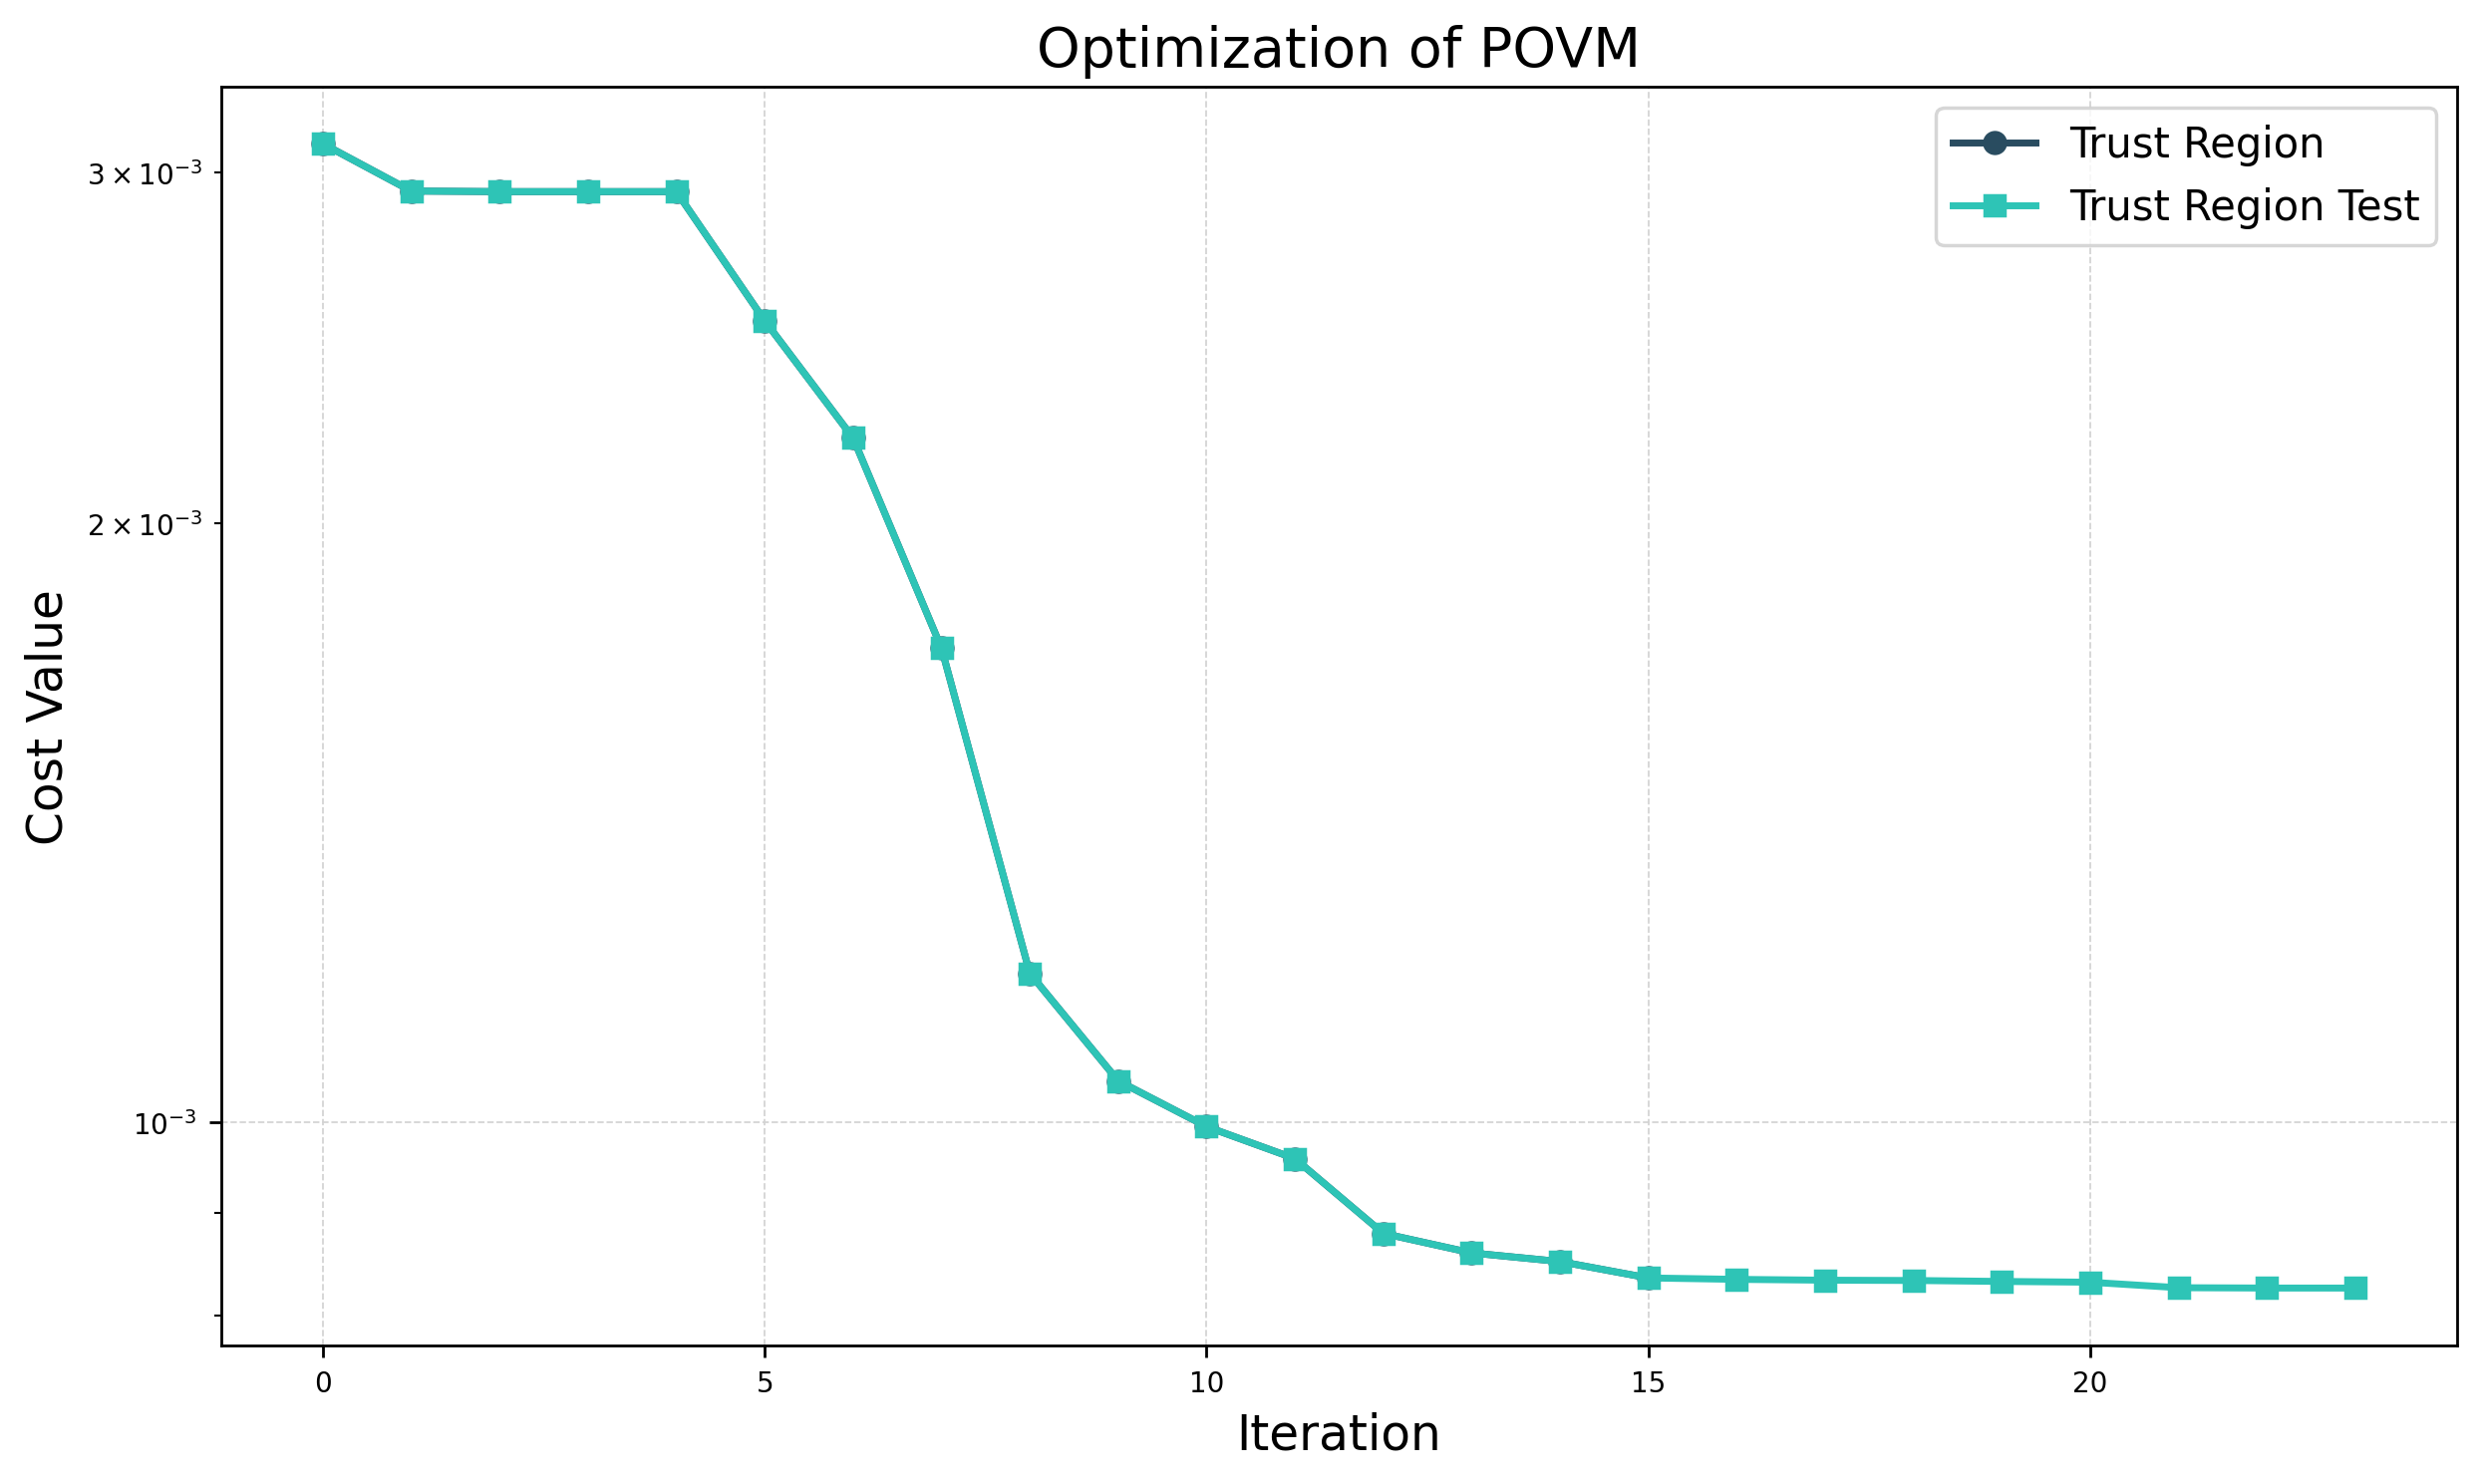

In [116]:
title = "Optimization of POVM"
cost_array_test = [cost_fx_optimized, cost_fx_optimized_test]
labels_test = ["Trust Region", "Trust Region Test"]
plot_cost_function(cost_array=cost_array_test, title=title, labels=labels_test)

# Compare against other methods

In [26]:
# We have to find a way to perform optimization only on the POVM elements.
def gradient_descent_povm(x_init:Tensor, cost_fn:Callable, init_step:float, num_iterations:int, cost_fn_kwargs:dict, optimize_step:bool=True, use_geodesic:bool=True, ls_max_iter:int=200, ls_method:str="COBYLA", metric="canonical", verbose:bool=True):
    """Perform gradient descent optimization on the POVM elements."""
    x_k = x_init
    step_k = init_step
    cost_k = cost_fn(x_k) 
    cost_fn_array = [cost_k]
    x_k_array = [x_k]
    
    kraus_tensor = cost_fn_kwargs["kraus_tensor"]
    state_psd = cost_fn_kwargs["state_psd"]
    indices_list = cost_fn_kwargs["indices_list"]
    prob_matrix = cost_fn_kwargs["prob_matrix"]
    
    print("Gradient Descent Optimization 🔋")
    for idx in range(num_iterations):
        print(f"Iteration {idx+1}/{num_iterations}, Cost function: {cost_k}, Step size: {step_k}")
        x_k, step_k = _update_tensor_via_gradient("povm", kraus_tensor=kraus_tensor, povm_psd=x_k, state_psd=state_psd, indices_list=indices_list, prob_matrix=prob_matrix, ls_method=ls_method, ls_max_iter=ls_max_iter, optimize_step=optimize_step, initial_step=step_k, use_geodesic=use_geodesic, regularized=False, metric=metric, verbose=verbose)
    
        cost_k = cost_fn(x_k)
        cost_fn_array.append(cost_k)
        x_k_array.append(x_k)

    return x_k, jnp.array(x_k_array), jnp.array(cost_fn_array)

def sf_newton_povm(x_init:Tensor, cost_fn:Callable, num_iterations:int, cost_fn_kwargs:dict):
    """Perform saddle-free Newton optimization on the POVM elements.
    
    In this method:
    * line search method is performed by default.
    * Geodesic is used by default.
    * LS num iterations uses default by scipy `minimize`.
    * LS method is COBYLA by default.
    """
    x_k = x_init
    cost_k = cost_fn(x_k) 
    cost_fn_array = [cost_k]
    x_k_array = [x_k]
    
    kraus_tensor = cost_fn_kwargs["kraus_tensor"]
    state_psd = cost_fn_kwargs["state_psd"]
    indices_list = cost_fn_kwargs["indices_list"]
    prob_matrix = cost_fn_kwargs["prob_matrix"]

    print("Saddle-Free Newton Optimization 🚨")
    for idx in range(num_iterations):
        print(f"Iteration {idx+1}/{num_iterations}, Cost function: {cost_k},")
        x_k = update_povm_via_saddle_free_newton(
            kraus_tensor=kraus_tensor,
            povm_psd=x_k,
            state_psd=state_psd,
            indices_list=indices_list,
            prob_matrix=prob_matrix,
        )
        
        cost_k = cost_fn(x_k)
        cost_fn_array.append(cost_k)
        x_k_array.append(x_k)

    return x_k, jnp.array(x_k_array), jnp.array(cost_fn_array)

cost_fn_kwargs = {
    "kraus_tensor": kraus_tensor_init_jax,
    "state_psd": state_psd_init_jax,
    "indices_list": indices_list_2q,
    "prob_matrix": prob_matrix_2q_sampled
}

In [27]:
x_optimized_gds, x_array_optimized_gds, cost_fx_optimized_gds = gradient_descent_povm(
    x_init=x,
    cost_fn=cost_fn_povm,
    init_step=1.0,
    num_iterations=20,
    cost_fn_kwargs=cost_fn_kwargs,
    metric="canonical",
    verbose=False,
)

Gradient Descent Optimization 🔋
Iteration 1/20, Cost function: 0.0031009132280137254, Step size: 1.0
Iteration 2/20, Cost function: 0.002966220180103963, Step size: [18.16450664]
Iteration 3/20, Cost function: 0.002940863173819487, Step size: [24.89664023]
Iteration 4/20, Cost function: 0.0029355537327170455, Step size: [18.69615664]
Iteration 5/20, Cost function: 0.0029343034728038305, Step size: [25.4059293]
Iteration 6/20, Cost function: 0.0029339946854865366, Step size: [19.01481602]
Iteration 7/20, Cost function: 0.002933912307435703, Step size: [25.97589766]
Iteration 8/20, Cost function: 0.002933889202467453, Step size: [19.37975039]
Iteration 9/20, Cost function: 0.0029338821688977717, Step size: [26.65831484]
Iteration 10/20, Cost function: 0.0029338799194512, Step size: [19.74738203]
Iteration 11/20, Cost function: 0.002933879147347835, Step size: [27.25822422]
Iteration 12/20, Cost function: 0.002933878872765272, Step size: [20.01613672]
Iteration 13/20, Cost function: 0.002

In [29]:
x_optimized_gds_euclidean, x_array_optimized_gds_euclidean, cost_fx_optimized_gds_euclidean = gradient_descent_povm(
    x_init=x,
    cost_fn=cost_fn_povm,
    init_step=1.0,
    num_iterations=20,
    cost_fn_kwargs=cost_fn_kwargs,
    metric="euclidean",
    verbose=False,
)

Gradient Descent Optimization 🔋
Iteration 1/20, Cost function: 0.0031009132280137254, Step size: 1.0
Iteration 2/20, Cost function: 0.0029662201801000975, Step size: [36.32875742]
Iteration 3/20, Cost function: 0.002940863040963051, Step size: [49.79398945]
Iteration 4/20, Cost function: 0.002935553692764169, Step size: [37.3919457]
Iteration 5/20, Cost function: 0.0029343034572554437, Step size: [50.81254414]
Iteration 6/20, Cost function: 0.002933994681014391, Step size: [38.02964102]
Iteration 7/20, Cost function: 0.002933912306358618, Step size: [51.95141602]
Iteration 8/20, Cost function: 0.0029338892021156856, Step size: [38.76010977]
Iteration 9/20, Cost function: 0.002933882168575696, Step size: [53.31489727]
Iteration 10/20, Cost function: 0.0029338799187737068, Step size: [39.50034414]
Iteration 11/20, Cost function: 0.002933879145498764, Step size: [54.54701914]
Iteration 12/20, Cost function: 0.0029338788684211575, Step size: [40.18676758]
Iteration 13/20, Cost function: 0.

In [21]:
x_optimized_sfn, x_array_optimized_sfn, cost_fx_optimized_sfn = sf_newton_povm(
    x_init=x,
    cost_fn=cost_fn_povm,
    num_iterations=20,
    cost_fn_kwargs=cost_fn_kwargs,
)

Saddle-Free Newton Optimization 🚨
Iteration 1/20, Cost function: 0.0031009132280137254,
Iteration 2/20, Cost function: 0.0029339601126951442,
Iteration 3/20, Cost function: 0.002933878722217012,
Iteration 4/20, Cost function: 0.0029338787074183964,
Iteration 5/20, Cost function: 0.0029338566772851653,
Iteration 6/20, Cost function: 0.001795921195274102,
Iteration 7/20, Cost function: 0.0010606259770956673,
Iteration 8/20, Cost function: 0.000873066182597035,
Iteration 9/20, Cost function: 0.0008387255155756919,
Iteration 10/20, Cost function: 0.0008335315744218549,
Iteration 11/20, Cost function: 0.0008328322639355444,
Iteration 12/20, Cost function: 0.0008324400847758148,
Iteration 13/20, Cost function: 0.0008292458110599685,
Iteration 14/20, Cost function: 0.0008257948054028455,
Iteration 15/20, Cost function: 0.0008254654951865638,
Iteration 16/20, Cost function: 0.0008254318475835391,
Iteration 17/20, Cost function: 0.0008254281171680566,
Iteration 18/20, Cost function: 0.000825427

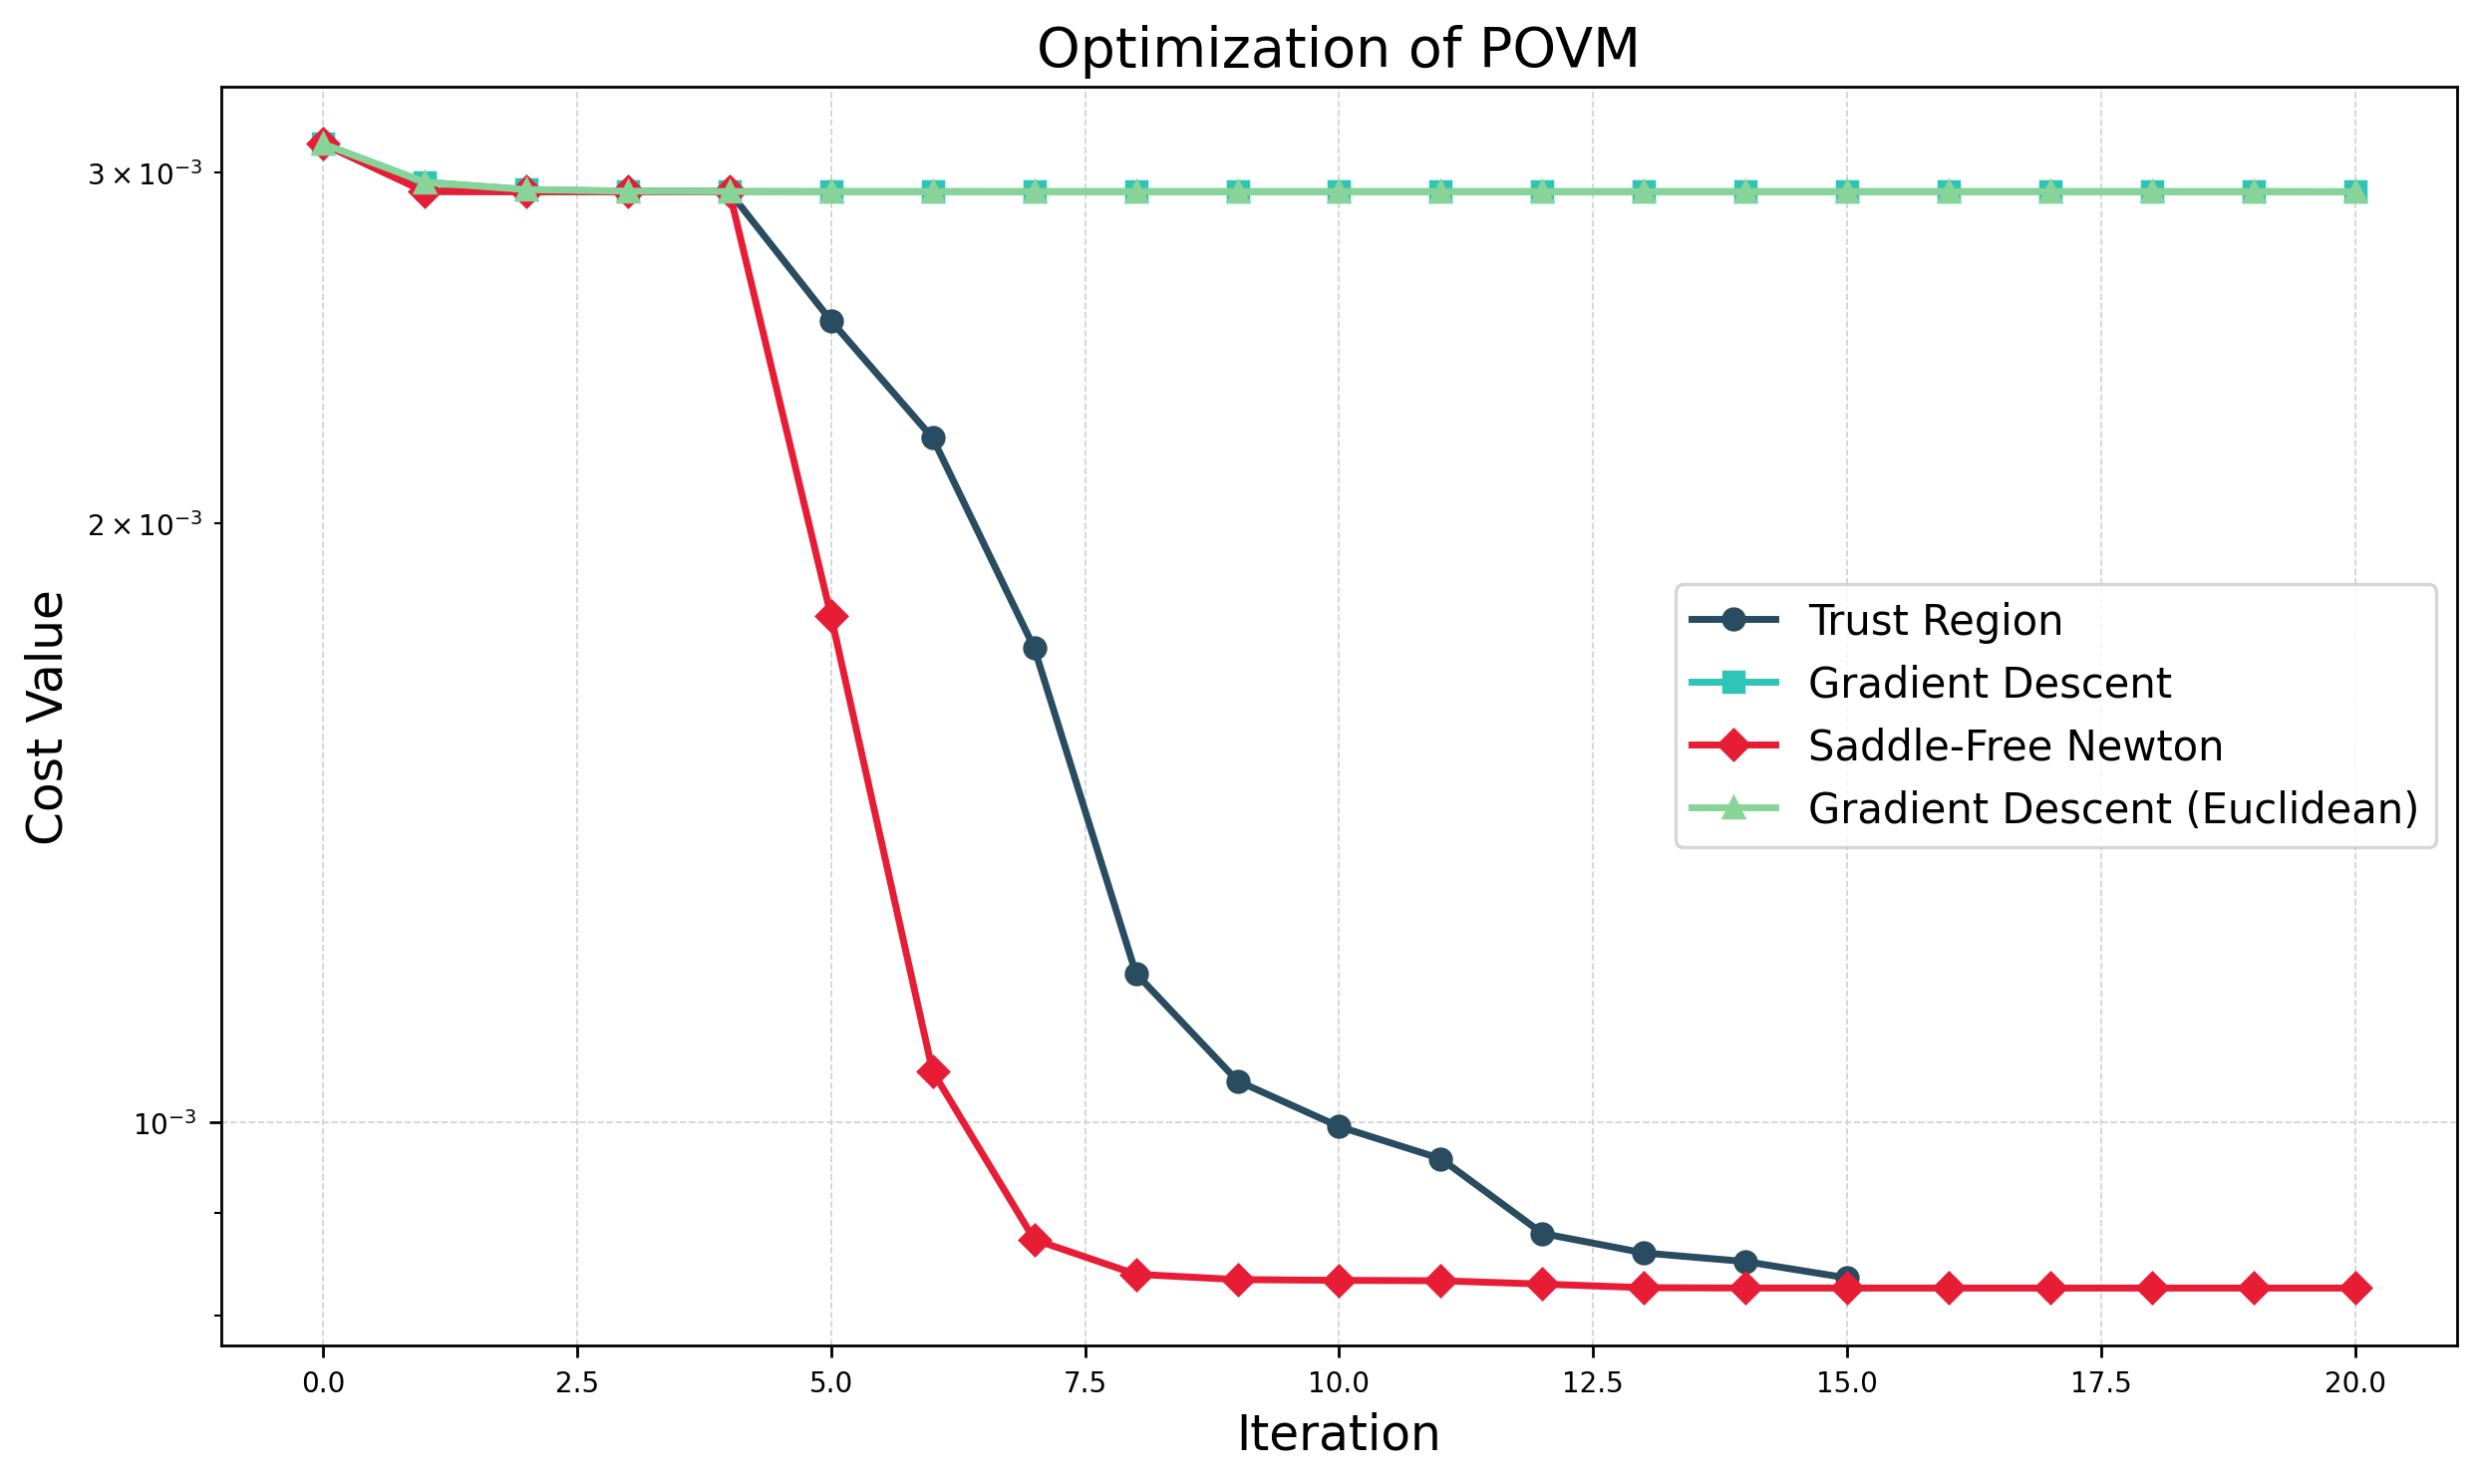

In [80]:
title = "Optimization of POVM"
cost_array = [cost_fx_optimized, cost_fx_optimized_gds, cost_fx_optimized_sfn, cost_fx_optimized_gds_euclidean]
labels = ["Trust Region", "Gradient Descent", "Saddle-Free Newton", "Gradient Descent (Euclidean)"]
plot_cost_function(cost_array=cost_array, title=title, labels=labels)

In [24]:
# Final cost functions:
xk_optimized_array = [x_optimized, x_optimized_gds, x_optimized_sfn]
final_cost = [cost_fn_povm(xk) for xk in xk_optimized_array]
print("Final costs:", final_cost)

initial_cost_array = [array[0] for array in cost_array]
ratios = [initial_value / final_value for initial_value, final_value in zip(initial_cost_array, final_cost)]
print("Ratios:", ratios)

Final costs: [Array(0.00083514, dtype=float64), Array(0.00293388, dtype=float64), Array(0.00082543, dtype=float64)]
Ratios: [Array(3.71302769, dtype=float64), Array(1.05693301, dtype=float64), Array(3.75673594, dtype=float64)]


Ratio: 4.519155607356383


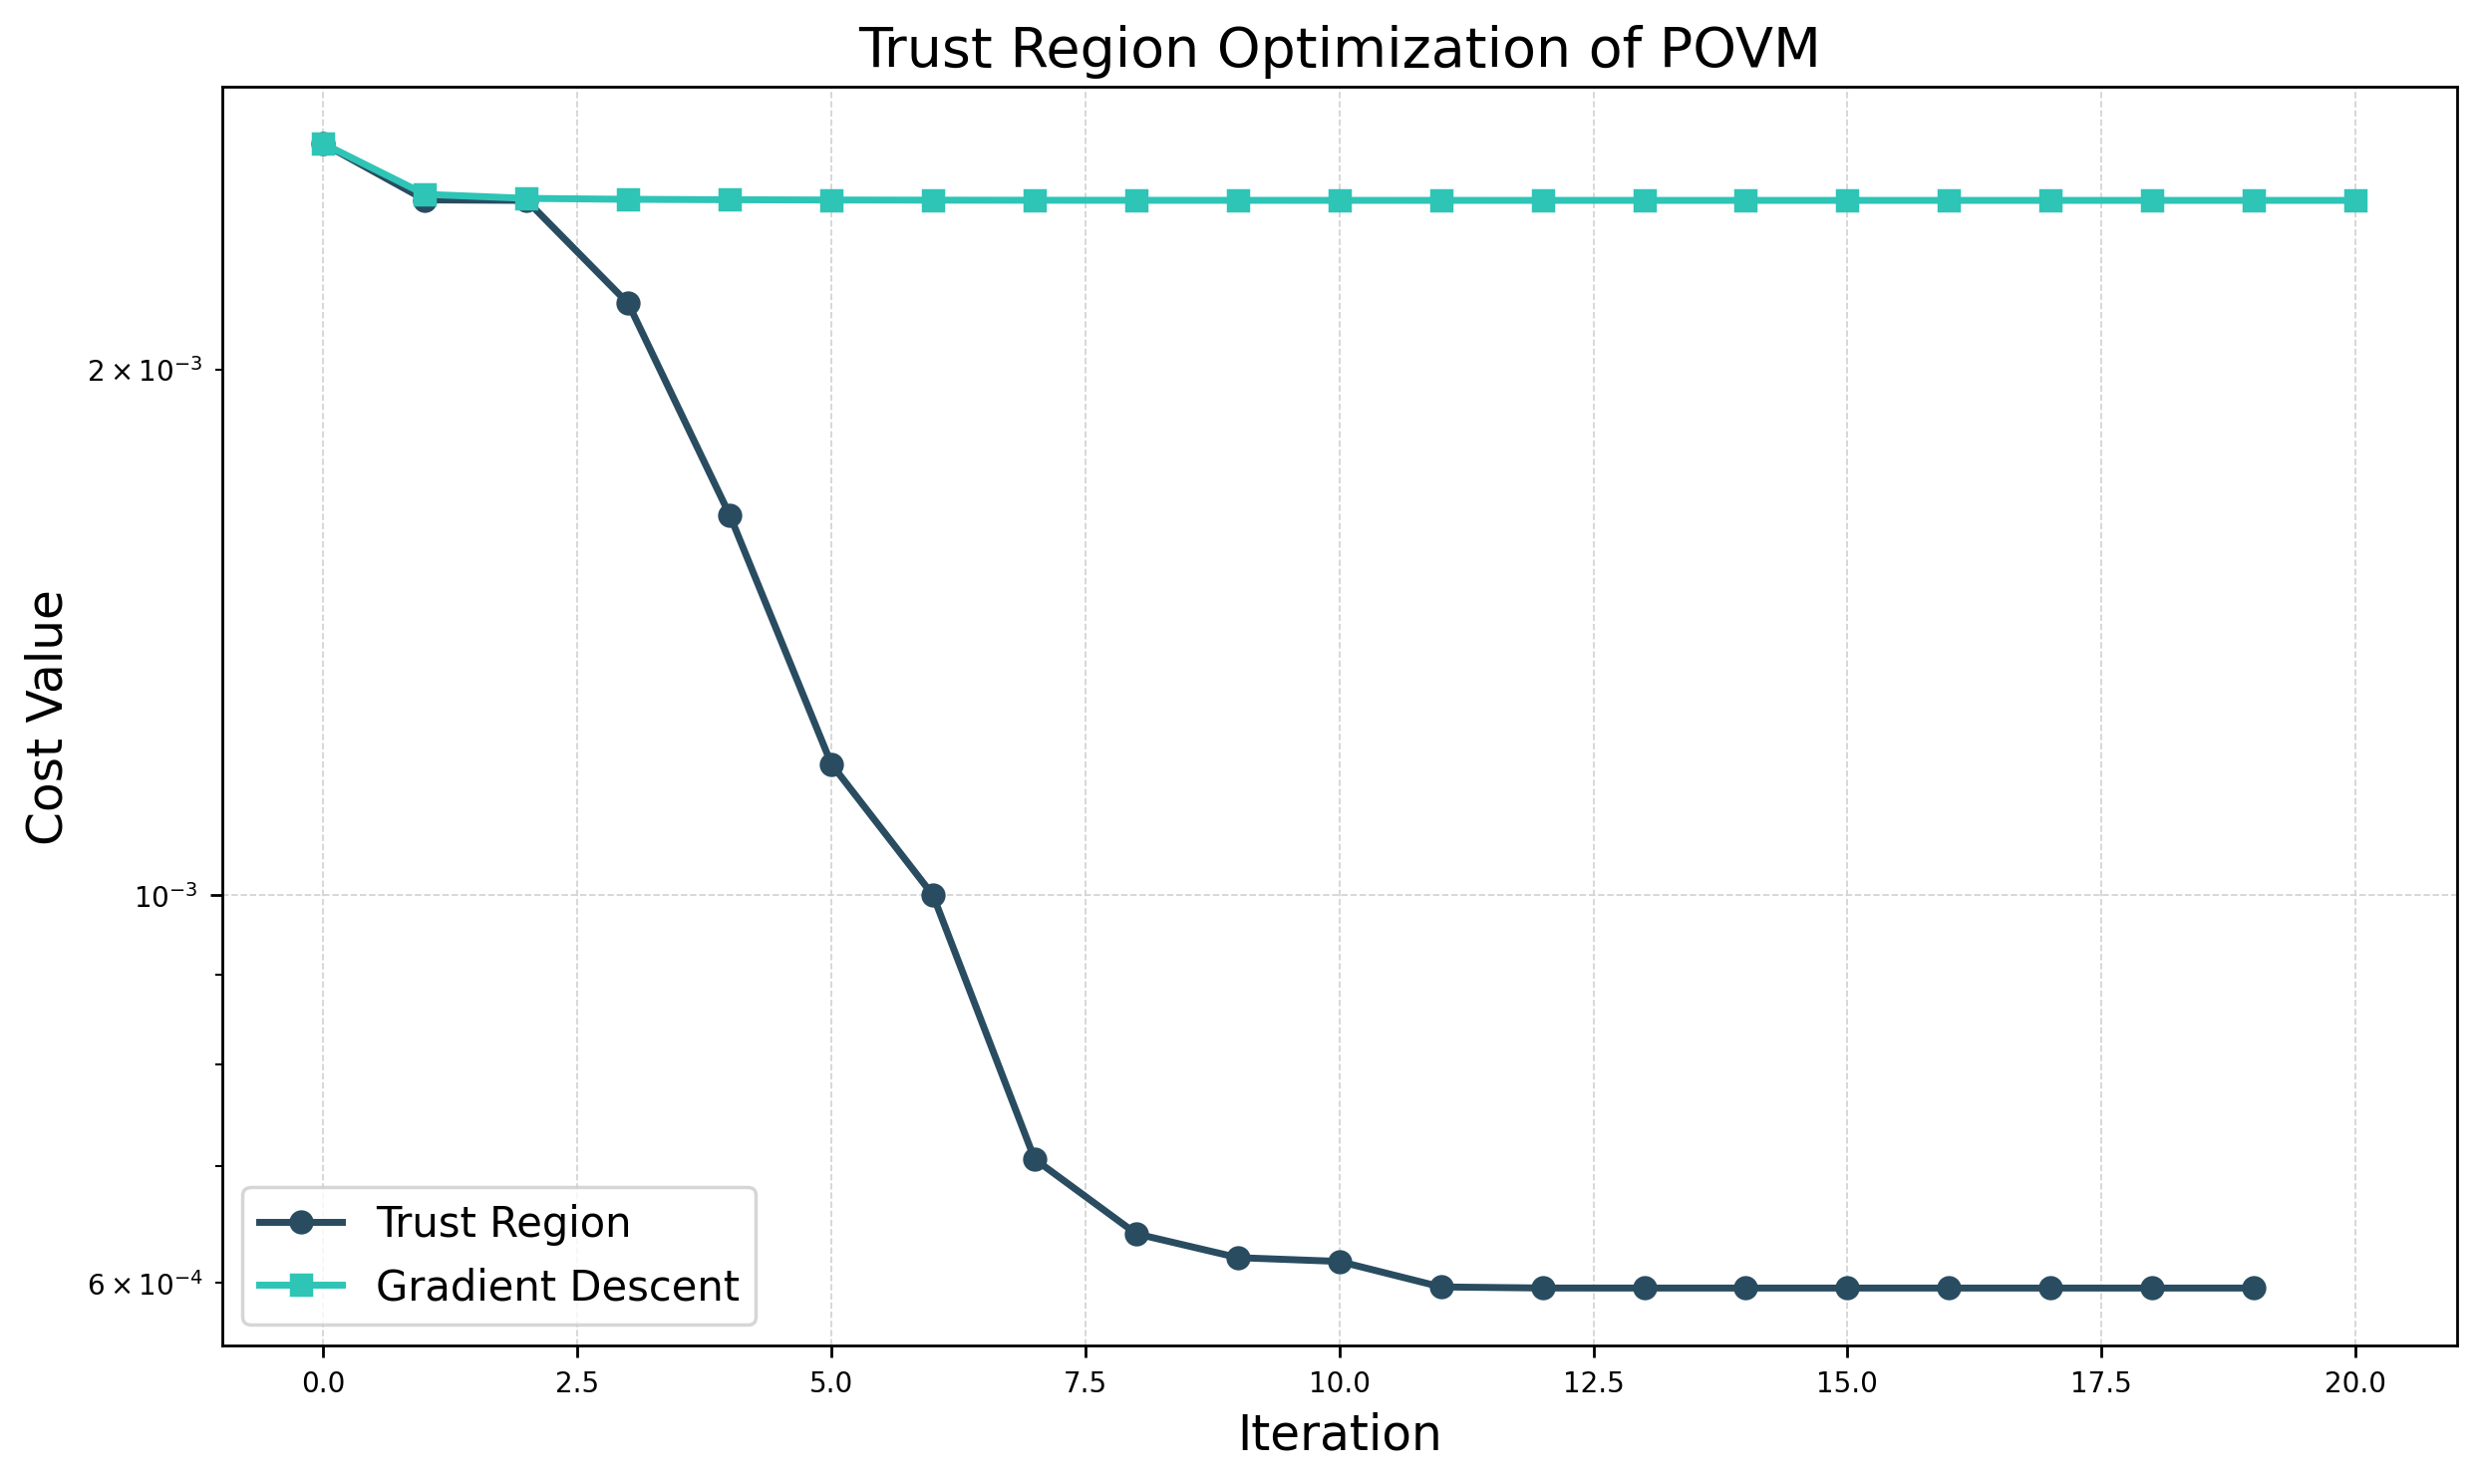

In [ ]:
# From previous run.
# print(f"Ratio: {cost_fx_optimized[0]/cost_fx_optimized[-1]}")
# plot_cost_function(cost_array=cost_array, title=title, labels=labels)

# Timing performance

In [31]:
# Time the performance of one SFN iteration.
%timeit update_povm_via_saddle_free_newton(povm_psd=x, **cost_fn_kwargs)

684 ms ± 15.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [33]:
# Time the performance of the GDS.
%timeit _update_tensor_via_gradient(operator_type="povm", povm_psd=x, verbose=False, **cost_fn_kwargs)

241 ms ± 9.63 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [37]:
# Time individual elements of the TR algorithm.
%timeit compute_quality_quotient(x=x, update_direction=gradient_init, cost_function=cost_fn_povm, x_next=x, n=n, p=p)

65.9 ms ± 2.08 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [38]:
%timeit riemannian_gradient_function(x)

42.8 ms ± 302 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [40]:
%timeit rhessian_vector_fn(x, gradient_init)

57.5 ms ± 908 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [52]:
%timeit compute_step_size(z=gradient_init_matrix, delta=gradient_init_matrix, x=x_matrix, radius=radius_init, metric=metric)

782 μs ± 17.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [72]:
sfn_avg, sfn_std = (684e-3, 15.4e-3)
gds_avg, gds_std = (241e-3, 9.63e-3)

tr_times = [(65.9e-3, 2.08e-3), (42.8e-3, 302e-6)]  # (mean, std) for quotient, gradient
tr_main_avg, tr_main_std = average_and_error_of_sum(*tr_times)
hz_avg, hz_std = (57.5e-3, 908e-6)
# How many times can we repeat the hessian-vec-time until the TR time matches the SFN time?
hz_repeats = (sfn_avg - tr_main_avg) / hz_avg
# Assume we perform half of those repeats in average.
hz_repeats_estimation = hz_repeats//2
hz_scaled_avg, hz_scaled_std = average_and_error_times_scalar((hz_avg, hz_std), hz_repeats_estimation)
# Total estimated time for TR iteration.
tr_total_avg, tr_total_std = average_and_error_of_sum((tr_main_avg, tr_main_std), (hz_scaled_avg, hz_scaled_std))
print(f"Trust Region average time: {tr_total_avg*1e3:.2f} ms ± {tr_total_std*1e3:.2f} ms")

Trust Region average time: 396.20 ms ± 5.00 ms


In [81]:
hz_repeats

10.005217391304347

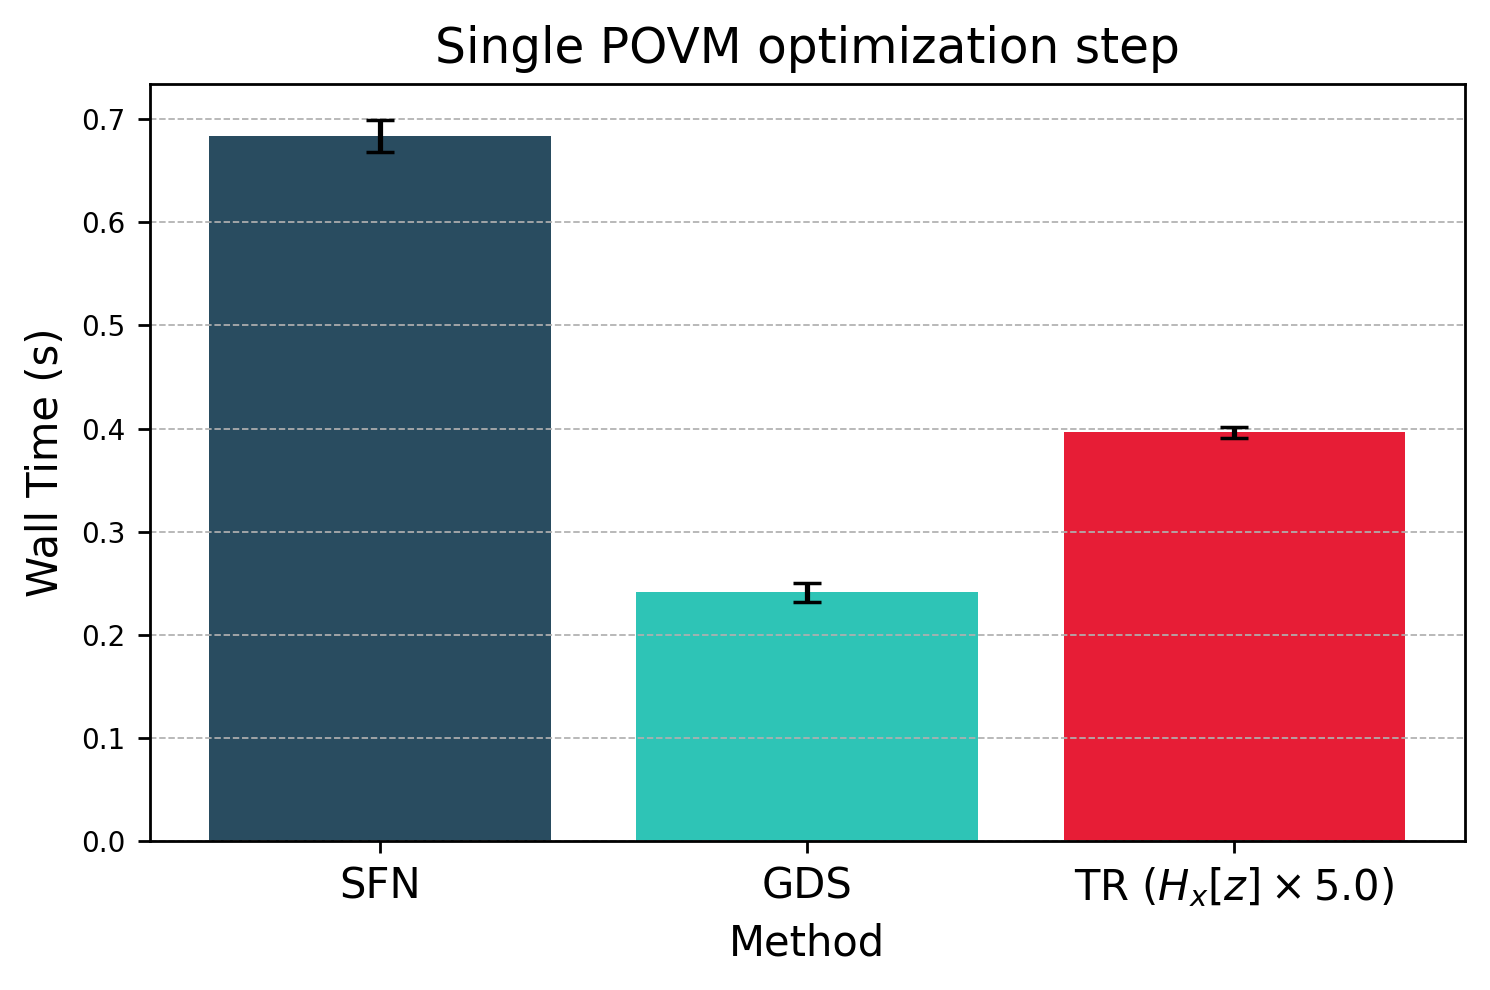

In [79]:
times_dict = {
    "SFN": (sfn_avg, sfn_std), # seconds
    "GDS": (gds_avg, gds_std), # seconds
    rf"TR ($H_x[z] \times {hz_repeats_estimation}$)": (tr_total_avg, tr_total_std) # seconds
}

plot_bars_with_error(
    data=times_dict,
    title="Single POVM optimization step",
    ylabel="Wall Time (s)",
    xlabel="Method",
)

# Compute full Hessian

(2, 64, 2, 64)


Text(0.5, 0, 'Index')

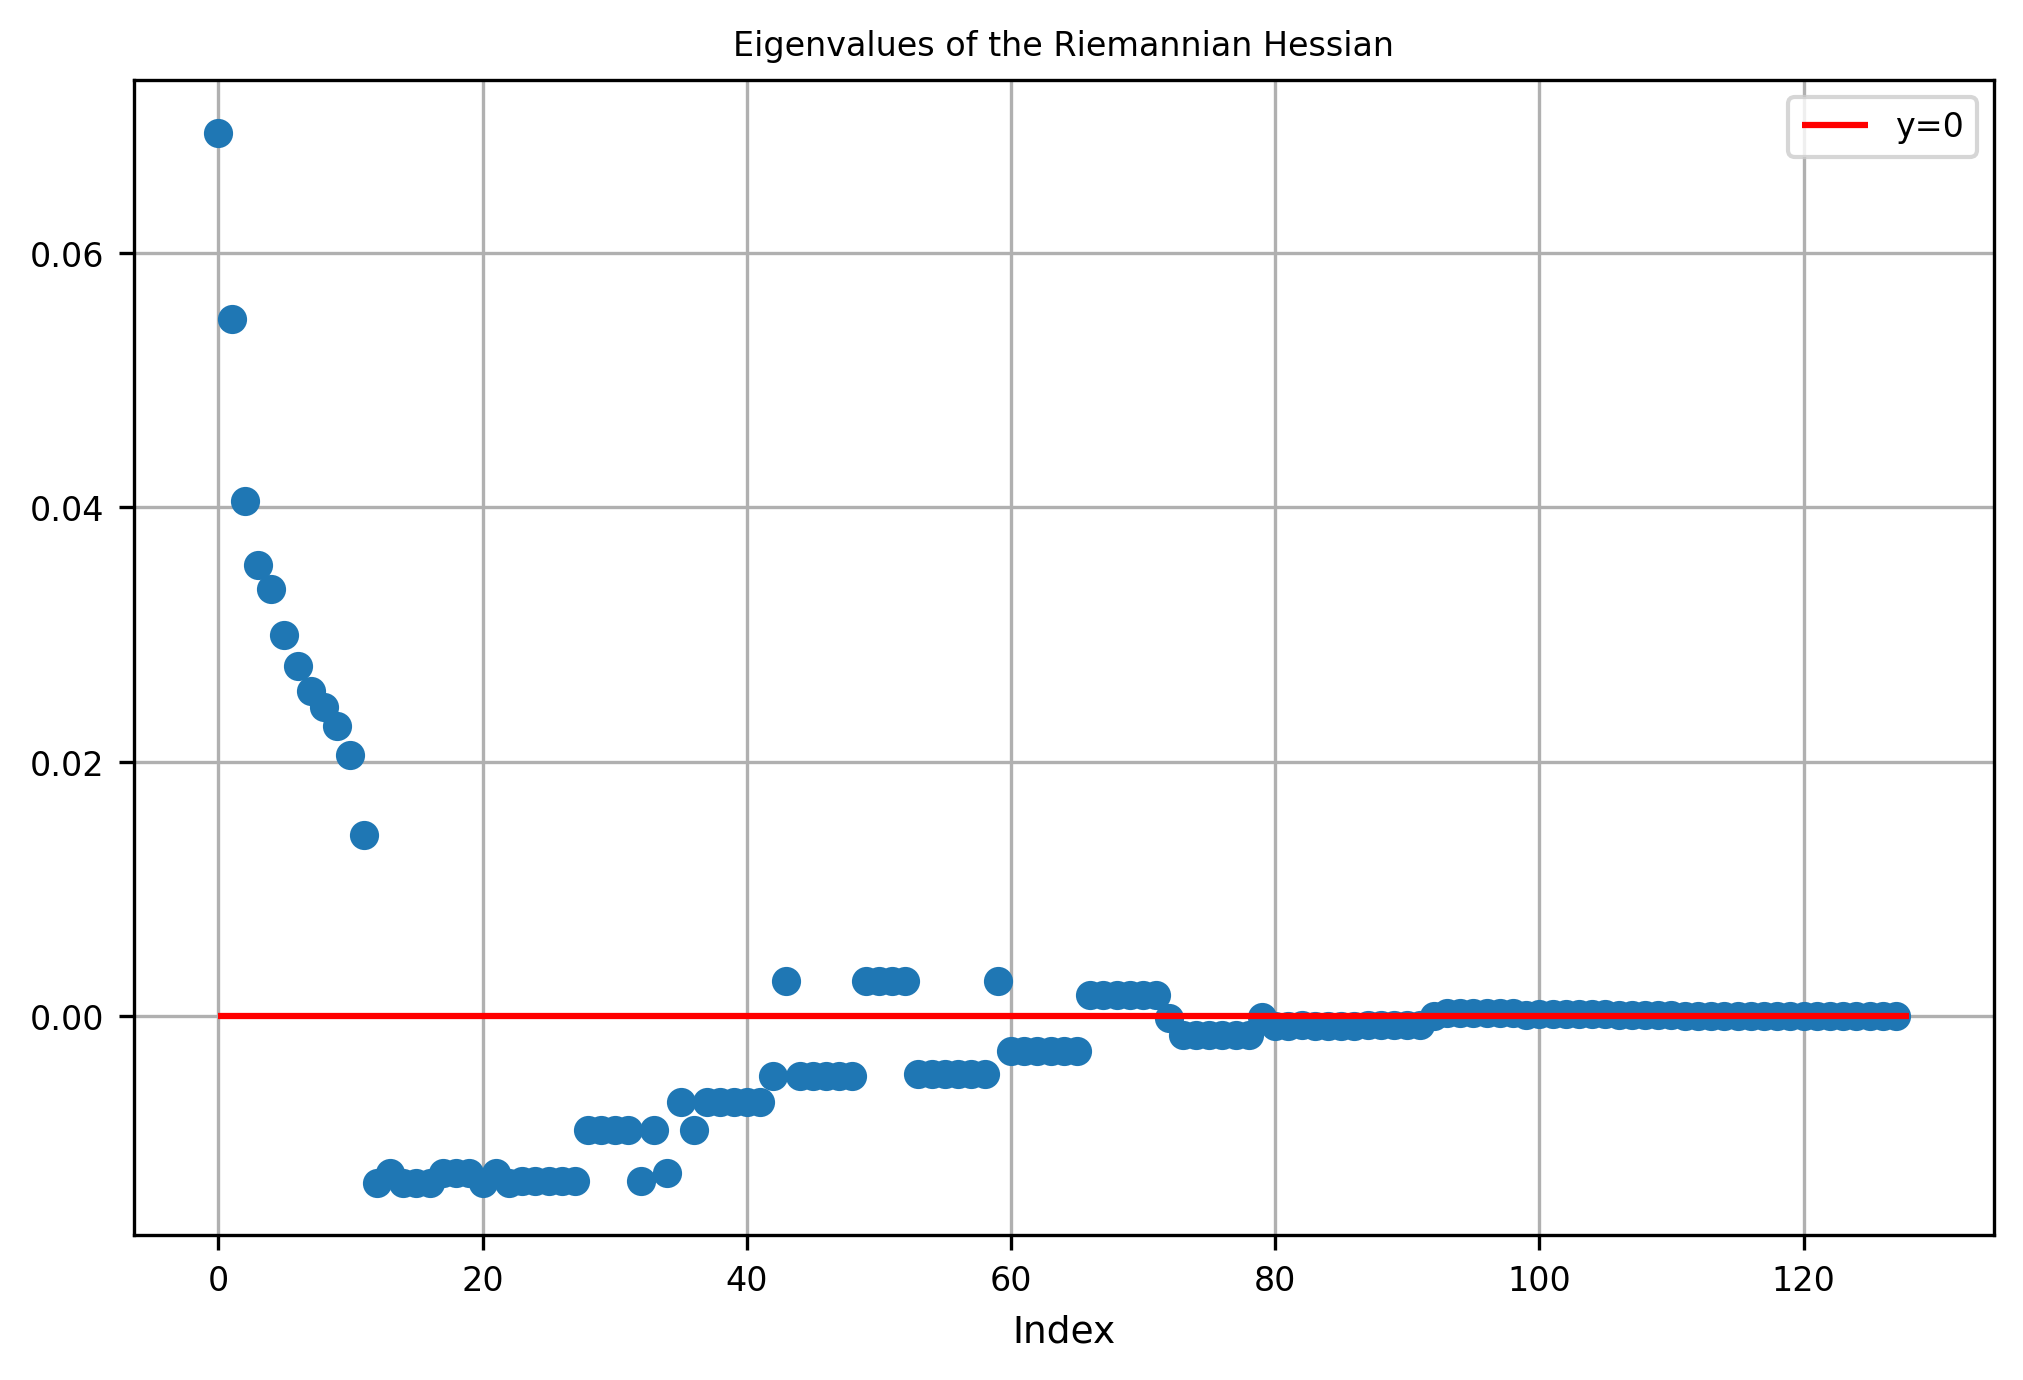

In [82]:
# Compute the full Hessian (using mGST) and its eigenvalues.
rhessian_tensor, rgradient_tensor = riemannian_hessian_povm(
    K=kraus_init_mgst,
    A=povm_psd_init_mgst,
    B=state_psd_init_mgst,
    y=prob_matrix_2q_sampled,
    J=indices_list_2q,
    return_gradient=True
)
print(rhessian_tensor.shape) # 2, n*p, 2, n*p
rhessian_matrix = rhessian_tensor.reshape(2 * n * p, 2 * n * p)
eigvals, eigvects = jnp.linalg.eig(rhessian_matrix)
plt.figure(figsize=(8, 5), dpi=300)
plt.plot(jnp.real(eigvals), 'o')
plt.hlines(y=0, xmin=0, xmax=len(eigvals), colors='r', label="y=0")
plt.title('Eigenvalues of the Riemannian Hessian')
plt.grid()
plt.legend()
plt.xlabel('Index')

# Checking conventions for gradient and Hessian-vector product

In [53]:
# Are gradients the same (up to a factor of 2)?
gradient_mgst_matrix = rgradient_tensor[0] # [grad, grad*], shape = (2, n*p)
gradient_mgst_tensor = isometry_to_tensor(gradient_mgst_matrix, gradient_init.shape)
jnp.allclose(2*gradient_mgst_tensor, gradient_init)

Array(True, dtype=bool)

In [ ]:
# Are the Hessian-vector products the same?
z_test = random_tangent_vector(x=x_matrix, n=n, p=p, seed=42)
hz_test_mgst = riemannian_hessian_vector_mgst(2*rhessian_tensor, z_test) # Add the factor of 2 here to see if adding it globally to the Hessian works
hz_test_mgst_tensor = isometry_to_tensor(hz_test_mgst, gradient_init.shape)

z_tensor_test = isometry_to_tensor(z_test, x.shape)
hz_test_jax = rhessian_vector_fn(x=x, tangent_vector=z_tensor_test)

jnp.allclose(hz_test_mgst_tensor, hz_test_jax)

Using JAX power


Array(True, dtype=bool)

In [56]:
# What about with the gradient
hz_test_mgst_2 = riemannian_hessian_vector_mgst(rhessian_tensor, gradient_mgst_matrix)
hz_test_mgst_2_tensor = isometry_to_tensor(hz_test_mgst_2, gradient_init.shape)
hz_test_jax_2 = rhessian_vector_fn(x=x, tangent_vector=gradient_init)

jnp.allclose(4*hz_test_mgst_2_tensor, hz_test_jax_2)

Using JAX power


Array(True, dtype=bool)

**Conclusion**:
- Gradient is the same up to a factor of 2
- Hessian-vector product is the same up to a factor of 2
- Hessian-gradient product (as expected) is the same up to a factor of 4 (2 from gradient, 2 from Hessian-vector product)

# Compute the exact solution

In [86]:
# Compute the exact solution.
rhessian_matrix_scaled = 2*rhessian_matrix
rgradient_vectorized = rgradient_tensor.reshape(-1)
epsilon = 1e-3
# 1st method through numpy inverse
dim_test = rhessian_matrix.shape[0] # 2*n*p
identity = jnp.eye(dim_test)
inverse_matrix = jnp.linalg.inv(rhessian_matrix_scaled + epsilon * identity)
subproblem_solution = ((inverse_matrix @ rgradient_vectorized)[:n * p]).reshape(n, p)

# 2nd method through eigenvalues
eigvals, eigvects = jnp.linalg.eig(rhessian_matrix_scaled)
processed_eigvals = jnp.abs(eigvals) + epsilon # is this correct?
inverse_matrix_2 = eigvects @ jnp.diag(1 / processed_eigvals) @ eigvects.T.conj()
subproblem_solution_2 = ((inverse_matrix_2 @ rgradient_vectorized)[:n * p]).reshape(n, p)

print("Are they the same?", jnp.allclose(subproblem_solution, subproblem_solution_2))

print("Norms: ", jnp.linalg.norm(inverse_matrix - inverse_matrix_2), jnp.linalg.norm(inverse_matrix), jnp.linalg.norm(inverse_matrix_2))

print("Does it invert?",
jnp.allclose(identity, rhessian_matrix_scaled @ inverse_matrix, atol=1e-5), jnp.allclose(identity, rhessian_matrix_scaled @ inverse_matrix_2, atol=1e-5))

Are they the same? False
Norms:  15114.397226771793 10767.642203758509 12416.74687636907
Does it invert? False False


In [ ]:
# 3rd method using penrose inverse
inverse_matrix_3 = jnp.linalg.pinv(rhessian_matrix_scaled)
subproblem_solution_3 = ((inverse_matrix_3 @ rgradient_vectorized)[:n * p]).reshape(n, p)
jnp.allclose(identity, inverse_matrix_3 @ rhessian_matrix_scaled, atol=1e-5)

(Array(False, dtype=bool), Array(0.0497095, dtype=float64))

In [ ]:
possible_solutions = [subproblem_solution, subproblem_solution_2, subproblem_solution_3]
for i, solution in enumerate(possible_solutions):
    print(f"Solution {i+1}")
    print(f"Norm = {jnp.linalg.norm(solution)}")
    print(f"In the tangent space? {is_in_tangent_space(x_matrix, solution)}")

Solution 1
Norm = 0.093718761639177
In the tangent space? False
Solution 2
Norm = 219976.36113354476
In the tangent space? False
Solution 3
Norm = 0.049709498640856636
In the tangent space? False


### Checking how these directions affect cost function:

In [173]:
cost_evaluations = []
for tangent_vector in possible_solutions:
    value = cost_fn_from_updated_povm_direction(tangent_vector)
    cost_evaluations.append(value)
cost_evaluations
    

[Array(0.00293409, dtype=float64),
 Array(0.04972581, dtype=float64),
 Array(0.00291387, dtype=float64)]

### Checking invertibility of matrix

In [107]:
jnp.abs(eigvals)[-20:]

Array([2.16684347e-04, 2.16684347e-04, 2.16684347e-04, 1.17152976e-14,
       1.08007968e-14, 8.41991767e-15, 6.94866757e-15, 2.34686536e-15,
       2.43083814e-15, 7.95457148e-17, 1.94962957e-15, 1.56550564e-15,
       5.31918173e-16, 3.56353577e-16, 3.56487564e-16, 8.12046323e-16,
       9.15560572e-16, 1.18551932e-15, 1.32313600e-15, 1.17643950e-15],      dtype=float64)

In [108]:
1/processed_eigvals[-20:], len(eigvals)

(Array([ 821.90586459,  821.90586459,  821.90586459,  999.99999999,
         999.99999999,  999.99999999,  999.99999999, 1000.        ,
        1000.        , 1000.        , 1000.        , 1000.        ,
        1000.        , 1000.        , 1000.        , 1000.        ,
        1000.        , 1000.        , 1000.        , 1000.        ],      dtype=float64),
 128)

In [122]:
s = np.linalg.svd(rhessian_matrix_scaled, compute_uv=False)
print("singular values (largest..smallest):", s[0], "...", s[-1])
threshold = 1/2.2e-16
condition_number = s[0]/s[-1]
print(f"cond: {condition_number}, above threshold? {condition_number > threshold}")

singular values (largest..smallest): 0.13944822637467702 ... 4.0182774164254497e-17
cond: 3470348408615510.0, above threshold? False
